# ProtoNet — Final Best Model

Trains the best ProtoNet configuration found during ablation (notebook 9) with the full **15,000 triplets/epoch** budget.

| Hyperparameter | Value |
|----------------|-------|
| `emb_dim`      | 256   |
| `margin`       | 0.5   |
| `freeze_until` | layer3|
| `preprocessing`| clahe |
| `n_support`    | 10    |
| `n_triplets`   | 15 000 |
| `max_epochs`   | 30    |
| `patience`     | 7     |

## 1. Imports & Setup

In [1]:
import sys, os, random, pickle
sys.path.insert(0, os.path.abspath('.'))

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision.models as tvm
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, Dataset
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split

from src.dataset import build_image_index, CrackDataset, save_splits, load_splits
from src.train_utils import calibrate_threshold, compute_metrics, print_metrics
from src.viz_utils import (
    plot_score_histogram, plot_roc_curve, plot_pr_curve,
    plot_confusion_matrix,
)

# ── Reproducibility ──────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# ── Paths ────────────────────────────────────────────────────────────────────
DATASET_DIR  = 'SDNET2018'
SPLITS_DIR   = 'splits'
CKPT_DIR     = 'checkpoints'
RESULTS_DIR  = 'results'
os.makedirs(CKPT_DIR,    exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

# ── Training hyperparameters ─────────────────────────────────────────────────
LR           = 3e-4
WEIGHT_DECAY = 1e-4
MAX_EPOCHS   = 20
PATIENCE     = 7
BATCH_SIZE   = 32
NUM_WORKERS  = 0

# ── Best hyperparameters (from notebook 9 ablation) ─────────────────────────
BEST_EMB_DIM      = 256
BEST_MARGIN       = 0.5
BEST_FREEZE       = 'layer3'
BEST_PREPROCESSING= 'clahe'
BEST_N_SUPPORT    = 10
BEST_N_TRIPLETS   = 15_000

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device  : {DEVICE}')
print(f'PyTorch : {torch.__version__}')
print(f'CUDA    : {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU     : {torch.cuda.get_device_name(0)}')
    print(f'VRAM    : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

Device  : cuda
PyTorch : 2.10.0+cu128
CUDA    : True
GPU     : NVIDIA GeForce RTX 3050 Laptop GPU
VRAM    : 4.3 GB


## 2. Data Splits

In [2]:
splits_exist = all(
    os.path.exists(os.path.join(SPLITS_DIR, f'patch_index_{s}.pkl'))
    for s in ('train', 'val', 'test')
)

if splits_exist:
    train_records, val_records, test_records = load_splits(SPLITS_DIR)
    print('Loaded existing splits.')
else:
    print('Splits not found — regenerating...')
    all_records = build_image_index(DATASET_DIR)
    labels_all  = np.array([r['label'] for r in all_records])
    train_records, temp_records = train_test_split(
        all_records, test_size=0.30, stratify=labels_all, random_state=SEED)
    temp_labels = np.array([r['label'] for r in temp_records])
    val_records, test_records = train_test_split(
        temp_records, test_size=0.50, stratify=temp_labels, random_state=SEED)
    save_splits(train_records, val_records, test_records, SPLITS_DIR)

# ── Separate support set from training normals ───────────────────────────────
# Support set = small set of normals held out to build the prototype at inference.
# These images are NEVER seen during triplet training.
train_normal_idx = [i for i, r in enumerate(train_records) if r['label'] == 0]
rng = np.random.default_rng(SEED)
support_idx   = rng.choice(train_normal_idx, size=BEST_N_SUPPORT, replace=False).tolist()
support_set   = set(support_idx)
finetune_recs = [r for i, r in enumerate(train_records) if i not in support_set]
support_recs  = [train_records[i] for i in support_idx]

print(f'Train (all classes, excl. support) : {len(finetune_recs):,}')
print(f'  → normal : {sum(r["label"]==0 for r in finetune_recs):,}')
print(f'  → crack  : {sum(r["label"]==1 for r in finetune_recs):,}')
print(f'Support set (normal only)          : {len(support_recs):,}')
print(f'Val                                : {len(val_records):,}')
print(f'Test                               : {len(test_records):,}')

Loaded existing splits.
Train (all classes, excl. support) : 17,023
  → normal : 15,197
  → crack  : 1,826
Support set (normal only)          : 10
Val                                : 3,650
Test                               : 3,651


## 3. Dataset & DataLoader

In [3]:
class TripletDataset(Dataset):
    """Yields (anchor_normal, positive_normal, negative_crack) triplets."""

    def __init__(self, records, preprocessing='clahe', n_per_epoch=None):
        self.normal_recs = [r for r in records if r['label'] == 0]
        self.crack_recs  = [r for r in records if r['label'] == 1]
        assert len(self.normal_recs) > 1
        assert len(self.crack_recs)  > 0
        self.n_per_epoch = n_per_epoch or len(self.normal_recs)
        self._normal_ds  = CrackDataset(self.normal_recs, preprocessing=preprocessing, augment=True)
        self._crack_ds   = CrackDataset(self.crack_recs,  preprocessing=preprocessing, augment=True)

    def __len__(self):
        return self.n_per_epoch

    def __getitem__(self, _):
        anc_idx = random.randint(0, len(self.normal_recs) - 1)
        pos_idx = random.randint(0, len(self.normal_recs) - 2)
        if pos_idx >= anc_idx:
            pos_idx += 1
        neg_idx = random.randint(0, len(self.crack_recs) - 1)
        anchor,   _ = self._normal_ds[anc_idx]
        positive, _ = self._normal_ds[pos_idx]
        negative, _ = self._crack_ds[neg_idx]
        return anchor, positive, negative


def make_loaders(preprocessing=BEST_PREPROCESSING, n_support=BEST_N_SUPPORT,
                 n_triplets=BEST_N_TRIPLETS):
    """Build triplet train loader, val loader, test loader and support records."""
    if n_support == BEST_N_SUPPORT:
        ft_recs  = finetune_recs
        sup_recs = support_recs
    else:
        rng2 = np.random.default_rng(SEED)
        sidx = rng2.choice(train_normal_idx, size=n_support, replace=False).tolist()
        sset = set(sidx)
        ft_recs  = [r for i, r in enumerate(train_records) if i not in sset]
        sup_recs = [train_records[i] for i in sidx]

    triplet_ds = TripletDataset(ft_recs, preprocessing=preprocessing,
                                n_per_epoch=n_triplets)
    triplet_loader = DataLoader(triplet_ds, batch_size=BATCH_SIZE,
                                shuffle=True, num_workers=NUM_WORKERS)

    val_ds   = CrackDataset(val_records,  preprocessing=preprocessing)
    test_ds  = CrackDataset(test_records, preprocessing=preprocessing)
    val_loader  = DataLoader(val_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
    test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

    return triplet_loader, val_loader, test_loader, sup_recs


# Build loaders
triplet_loader, val_loader, test_loader, support_recs = make_loaders()
val_labels_arr  = np.array([r['label'] for r in val_records])
test_labels_arr = np.array([r['label'] for r in test_records])

print(f'Triplets per epoch : {len(triplet_loader.dataset):,}')
print(f'Batches per epoch  : {len(triplet_loader):,}')

Triplets per epoch : 15,000
Batches per epoch  : 469


## 4. Model Architecture

In [4]:
class ProtoNet(nn.Module):
    """ResNet-18 encoder + projection head for prototypical anomaly detection.

    Args:
        emb_dim:      Output embedding dimension (default 256).
        freeze_until: Freeze all layers up to and including this ResNet stage.
                      One of 'layer1', 'layer2', 'layer3'. Default 'layer3'.
        pretrained:   Use ImageNet weights for the encoder. Default True.
    """

    def __init__(self, emb_dim: int = 256, freeze_until: str = 'layer3',
                 pretrained: bool = True):
        super().__init__()
        weights  = tvm.ResNet18_Weights.IMAGENET1K_V1 if pretrained else None
        backbone = tvm.resnet18(weights=weights)

        self.encoder = nn.Sequential(
            backbone.conv1, backbone.bn1, backbone.relu, backbone.maxpool,
            backbone.layer1, backbone.layer2, backbone.layer3, backbone.layer4,
            nn.AdaptiveAvgPool2d((1, 1)),
        )

        # Freeze layers up to (and including) freeze_until
        freeze_map = {'layer1': 4, 'layer2': 5, 'layer3': 6}
        freeze_up_to = freeze_map.get(freeze_until, 6)
        for i, child in enumerate(self.encoder.children()):
            if i <= freeze_up_to:
                for p in child.parameters():
                    p.requires_grad = False

        # Projection head
        self.head = nn.Sequential(
            nn.Linear(512, 256, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(256, emb_dim, bias=False),
        )
        self.emb_dim = emb_dim
        self.register_buffer('prototype', torch.zeros(emb_dim))

    def embed(self, x: torch.Tensor) -> torch.Tensor:
        """Return L2-normalised embedding on the unit sphere."""
        feats = self.encoder(x).flatten(1)   # (B, 512)
        z     = self.head(feats)              # (B, emb_dim)
        return F.normalize(z, p=2, dim=1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.embed(x)

    def build_prototype(self, support_records, preprocessing, device):
        """Compute mean normal embedding from a support set of normal images."""
        self.eval()
        sup_ds = CrackDataset(support_records, preprocessing=preprocessing)
        loader = DataLoader(sup_ds, batch_size=len(sup_ds), shuffle=False)
        with torch.no_grad():
            imgs, _ = next(iter(loader))
            embs = self.embed(imgs.to(device))   # (N, emb_dim)
        self.prototype = embs.mean(dim=0)        # (emb_dim,)
        return self.prototype

    def anomaly_score(self, x: torch.Tensor) -> torch.Tensor:
        """L2 distance from embedding to prototype — higher = more anomalous."""
        z = self.embed(x)
        return torch.norm(z - self.prototype.unsqueeze(0), p=2, dim=1)


# Sanity check
_m = ProtoNet(emb_dim=BEST_EMB_DIM, freeze_until=BEST_FREEZE).to(DEVICE)
n_total     = sum(p.numel() for p in _m.parameters())
n_trainable = sum(p.numel() for p in _m.parameters() if p.requires_grad)
print(f'Total params     : {n_total:,}')
print(f'Trainable params : {n_trainable:,}  ({100*n_trainable/n_total:.1f}%)')
with torch.no_grad():
    _z = _m.embed(torch.randn(4, 3, 256, 256).to(DEVICE))
print(f'Embedding shape  : {tuple(_z.shape)}  (should be (4, {BEST_EMB_DIM}))')
print(f'Embedding norms  : {[f"{v:.4f}" for v in _z.norm(dim=1).tolist()]}  (should all be ~1.0)')
del _m

Total params     : 11,373,120
Trainable params : 8,590,336  (75.5%)
Embedding shape  : (4, 256)  (should be (4, 256))
Embedding norms  : ['1.0000', '1.0000', '1.0000', '1.0000']  (should all be ~1.0)


## 5. Training Helpers

In [5]:
def train_proto_epoch(model, loader, optimizer, device, margin):
    """One epoch of triplet training. Returns (avg_loss, fraction_active_triplets)."""
    model.train()
    total_loss, total_active, total_count = 0.0, 0, 0
    for anchor, positive, negative in loader:
        anchor, positive, negative = (
            anchor.to(device), positive.to(device), negative.to(device)
        )
        z_a = model.embed(anchor)
        z_p = model.embed(positive)
        z_n = model.embed(negative)
        d_ap = torch.norm(z_a - z_p, p=2, dim=1)
        d_an = torch.norm(z_a - z_n, p=2, dim=1)
        losses = F.relu(d_ap - d_an + margin)
        loss   = losses.mean()
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss   += loss.item()
        total_active += (losses > 0).sum().item()
        total_count  += len(anchor)
    return total_loss / len(loader), total_active / total_count


def eval_proto_scores(model, loader, device):
    """Return (scores, labels) numpy arrays for a data loader."""
    model.eval()
    all_scores, all_labels = [], []
    with torch.no_grad():
        for x, y in loader:
            all_scores.append(model.anomaly_score(x.to(device)).cpu().numpy())
            all_labels.append(y.numpy())
    return np.concatenate(all_scores), np.concatenate(all_labels)


print('Training helpers defined.')

Training helpers defined.


## 6. Train Final Model

In [6]:
model = ProtoNet(emb_dim=BEST_EMB_DIM, freeze_until=BEST_FREEZE).to(DEVICE)
optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR, weight_decay=WEIGHT_DECAY,
)
scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=MAX_EPOCHS, eta_min=1e-6
)

best_auroc = -1.0
best_state = None
no_improve = 0
train_losses, val_aurocs = [], []
ckpt_path = os.path.join(CKPT_DIR, 'proto_final.pt')

print(f'Training ProtoNet-Final')
print(f'  emb={BEST_EMB_DIM}, margin={BEST_MARGIN}, freeze={BEST_FREEZE}')
print(f'  pre={BEST_PREPROCESSING}, n_support={BEST_N_SUPPORT}, triplets/epoch={BEST_N_TRIPLETS:,}')
print()

for epoch in range(1, MAX_EPOCHS + 1):
    tr_loss, frac_active = train_proto_epoch(
        model, triplet_loader, optimizer, DEVICE, BEST_MARGIN)
    train_losses.append(tr_loss)
    scheduler.step()

    model.build_prototype(support_recs, BEST_PREPROCESSING, DEVICE)
    val_scores, val_lbl = eval_proto_scores(model, val_loader, DEVICE)
    val_auroc = float(roc_auc_score(val_lbl, val_scores))
    val_aurocs.append(val_auroc)

    marker = ' *' if val_auroc > best_auroc else ''
    print(f'Epoch {epoch:3d}/{MAX_EPOCHS}  loss={tr_loss:.6f}  '
          f'active={frac_active:.2%}  val_AUROC={val_auroc:.4f}{marker}')

    if val_auroc > best_auroc:
        best_auroc = val_auroc
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        no_improve = 0
        torch.save({
            'model_state': best_state,
            'emb_dim': BEST_EMB_DIM,
            'margin': BEST_MARGIN,
            'freeze_until': BEST_FREEZE,
            'preprocessing': BEST_PREPROCESSING,
            'n_support': BEST_N_SUPPORT,
        }, ckpt_path)
    else:
        no_improve += 1
        if no_improve >= PATIENCE:
            print(f'\n  Early stop at epoch {epoch} (best val_AUROC={best_auroc:.4f})')
            break

print(f'\nBest val_AUROC: {best_auroc:.4f}')
print(f'Checkpoint saved to: {ckpt_path}')

Training ProtoNet-Final
  emb=256, margin=0.5, freeze=layer3
  pre=clahe, n_support=10, triplets/epoch=15,000

Epoch   1/20  loss=0.124687  active=29.42%  val_AUROC=0.7802 *
Epoch   2/20  loss=0.002292  active=1.21%  val_AUROC=0.7828 *
Epoch   3/20  loss=0.007886  active=3.51%  val_AUROC=0.7282
Epoch   4/20  loss=0.004968  active=2.37%  val_AUROC=0.8337 *
Epoch   5/20  loss=0.002308  active=1.19%  val_AUROC=0.7310
Epoch   6/20  loss=0.000251  active=0.15%  val_AUROC=0.7401
Epoch   7/20  loss=0.009016  active=3.17%  val_AUROC=0.7467
Epoch   8/20  loss=0.000847  active=0.73%  val_AUROC=0.7750
Epoch   9/20  loss=0.006134  active=2.07%  val_AUROC=0.7750
Epoch  10/20  loss=0.001557  active=1.03%  val_AUROC=0.7806
Epoch  11/20  loss=0.002263  active=0.66%  val_AUROC=0.8036

  Early stop at epoch 11 (best val_AUROC=0.8337)

Best val_AUROC: 0.8337
Checkpoint saved to: checkpoints\proto_final.pt


## 7. Evaluate on Test Set

In [7]:
# Load best weights
model.load_state_dict(best_state)
model.build_prototype(support_recs, BEST_PREPROCESSING, DEVICE)

val_scores, val_lbl   = eval_proto_scores(model, val_loader,  DEVICE)
test_scores, test_lbl = eval_proto_scores(model, test_loader, DEVICE)

tau, _ = calibrate_threshold(val_scores, val_lbl)
metrics = compute_metrics(test_scores, test_lbl, tau)
metrics['threshold'] = tau
metrics['val_auroc'] = best_auroc

print_metrics(metrics, 'ProtoNet-Final')

# Save metrics
with open(os.path.join(RESULTS_DIR, 'proto_final_metrics.pkl'), 'wb') as f:
    pickle.dump(metrics, f)
print('Metrics saved.')

[ProtoNet-Final] AUROC: 0.8049  AUPRC: 0.6156  F1: 0.6065
  Confusion matrix:
    TN=  3203  FP=    57
    FN=   196  TP=   195
Metrics saved.


## 8. Training Curves

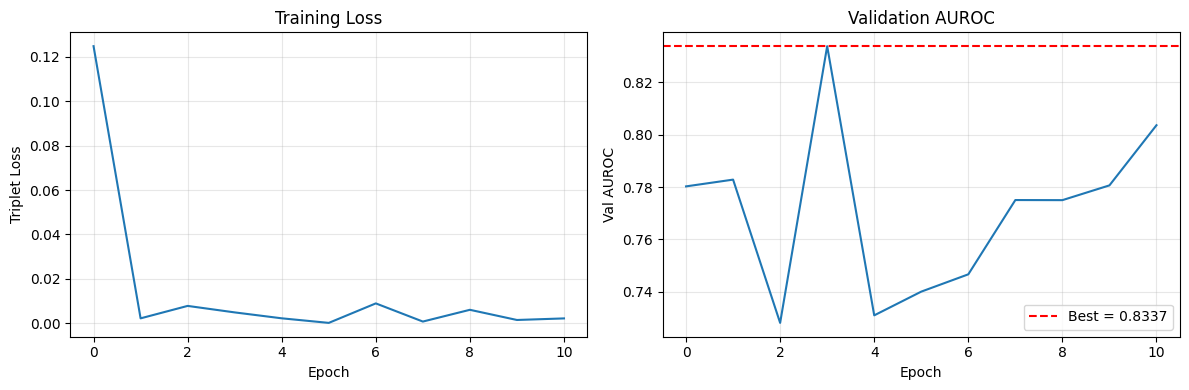

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(train_losses)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Triplet Loss')
ax1.set_title('Training Loss')
ax1.grid(True, alpha=0.3)

ax2.plot(val_aurocs)
ax2.axhline(max(val_aurocs), color='r', linestyle='--',
            label=f'Best = {max(val_aurocs):.4f}')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Val AUROC')
ax2.set_title('Validation AUROC')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'proto_final_curves.png'), dpi=150, bbox_inches='tight')
plt.show()

## 9. Diagnostic Plots

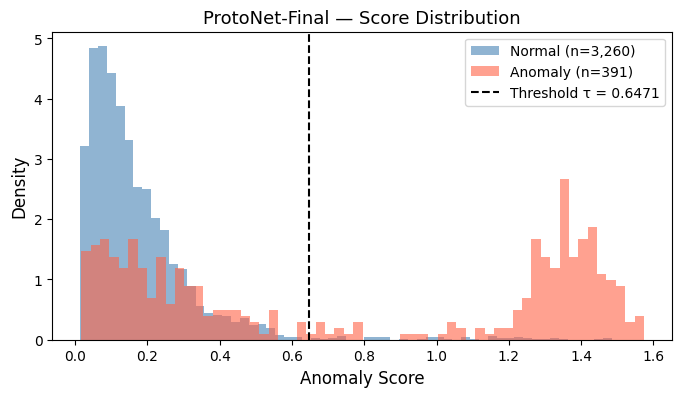

In [9]:
plot_score_histogram(test_scores, test_lbl, tau, title='ProtoNet-Final — Score Distribution')
plt.savefig(os.path.join(RESULTS_DIR, 'proto_final_histogram.png'), dpi=150, bbox_inches='tight')
plt.show()

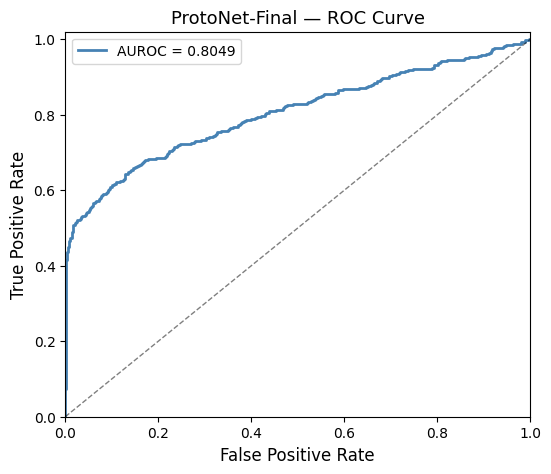

In [10]:
plot_roc_curve(test_scores, test_lbl, metrics['auroc'], title='ProtoNet-Final — ROC Curve')
plt.savefig(os.path.join(RESULTS_DIR, 'proto_final_roc.png'), dpi=150, bbox_inches='tight')
plt.show()

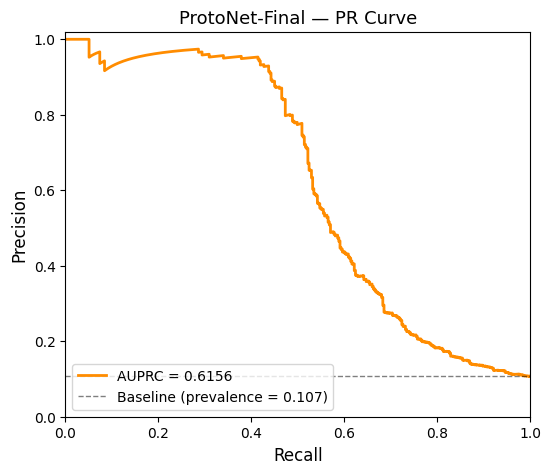

In [11]:
plot_pr_curve(test_scores, test_lbl, metrics['auprc'], title='ProtoNet-Final — PR Curve')
plt.savefig(os.path.join(RESULTS_DIR, 'proto_final_pr.png'), dpi=150, bbox_inches='tight')
plt.show()

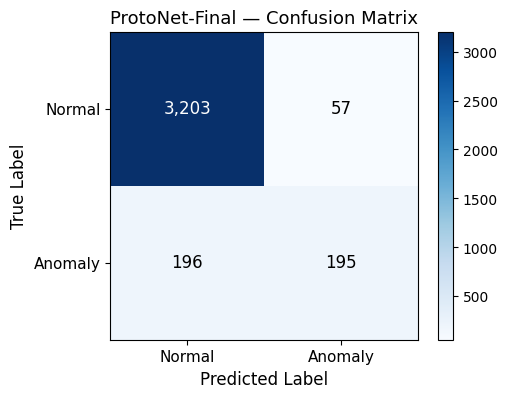

In [12]:
from sklearn.metrics import confusion_matrix as sk_confusion_matrix

preds = (test_scores >= tau).astype(int)
cm = sk_confusion_matrix(test_lbl, preds)
plot_confusion_matrix(cm, title='ProtoNet-Final — Confusion Matrix')
plt.savefig(os.path.join(RESULTS_DIR, 'proto_final_cm.png'), dpi=150, bbox_inches='tight')
plt.show()

## 10. Summary

In [13]:
print('=' * 65)
print(f'{"Model":<36} {"AUROC":>7}  {"AUPRC":>7}  {"F1":>7}')
print('-' * 65)
# Reference baselines (from previous notebooks)
baselines = [
    ('Binary CNN (supervised)',      0.9649, 0.8774, 0.7973),
    ('PatchCore EB4 (no-train)',     0.7744, 0.2656, 0.3755),
    ('S-T layer4 (baseline)',        0.7674, 0.2909, 0.3548),
    ('ProtoNet (baseline nb4)',      0.7673, 0.4876, 0.5131),
    ('ProtoNet-Best (nb9 ablation)', 0.8213, 0.6406, 0.6069),
]
for name, auroc, auprc, f1 in baselines:
    print(f'{name:<36} {auroc:.4f}  {auprc:.4f}  {f1:.4f}')
print('-' * 65)
print(f'{"ProtoNet-Final (this nb)":<36} {metrics["auroc"]:.4f}  {metrics["auprc"]:.4f}  {metrics["f1"]:.4f}  <-')
print('=' * 65)

Model                                  AUROC    AUPRC       F1
-----------------------------------------------------------------
Binary CNN (supervised)              0.9649  0.8774  0.7973
PatchCore EB4 (no-train)             0.7744  0.2656  0.3755
S-T layer4 (baseline)                0.7674  0.2909  0.3548
ProtoNet (baseline nb4)              0.7673  0.4876  0.5131
ProtoNet-Best (nb9 ablation)         0.8213  0.6406  0.6069
-----------------------------------------------------------------
ProtoNet-Final (this nb)             0.8049  0.6156  0.6065  <-


Loaded: proto_best_v2.pt  (emb=256, freeze=layer3)
Prototype built from 10 support images.
Decision threshold (tau): 0.3543


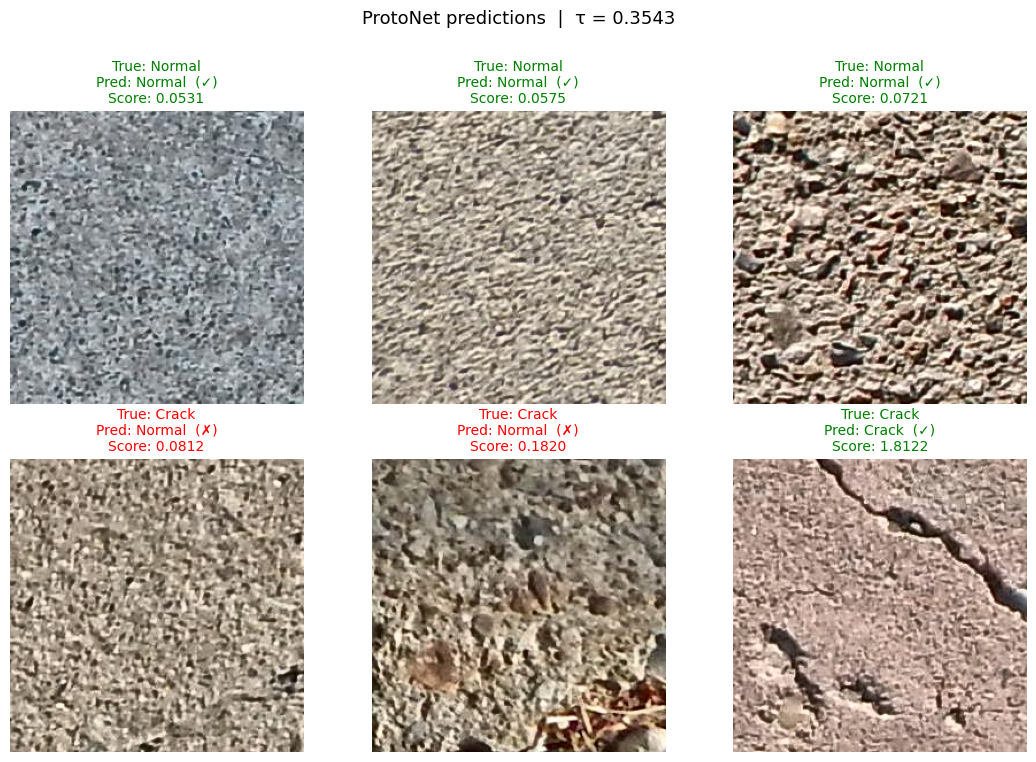

In [20]:
# ── Manual test: show 3 normal + 3 crack images with predictions ──────────────
import random
import matplotlib.pyplot as plt
import torch
import numpy as np
from src.dataset import CrackDataset

# ── Config — change CKPT_NAME if you want to test a different checkpoint ──────
CKPT_NAME     = 'proto_best_v2.pt'   # final best model from this notebook
PREPROCESSING = 'clahe'              # must match what the model was trained with
N_SUPPORT     = 10                   # must match training

# ── Denormalise helper ─────────────────────────────────────────────────────────
_MEAN = np.array([0.485, 0.456, 0.406])
_STD  = np.array([0.229, 0.224, 0.225])

def denorm(tensor):
    """(3,H,W) tensor → (H,W,3) numpy in [0,1], ready for imshow."""
    img = tensor.cpu().permute(1, 2, 0).numpy()
    img = img * _STD + _MEAN
    return np.clip(img, 0, 1)

# ── Load checkpoint ────────────────────────────────────────────────────────────
ckpt = torch.load(
    os.path.join(CKPT_DIR, CKPT_NAME),
    map_location=DEVICE, weights_only=True,
)
emb_dim      = ckpt.get('emb_dim',      256)
freeze_until = ckpt.get('freeze_until', 'layer3')

model_test = ProtoNet(emb_dim=emb_dim, freeze_until=freeze_until).to(DEVICE)
model_test.load_state_dict(ckpt['model_state'], strict=False)
model_test.eval()
print(f'Loaded: {CKPT_NAME}  (emb={emb_dim}, freeze={freeze_until})')

# ── Build prototype from support set ──────────────────────────────────────────
model_test.build_prototype(support_recs, PREPROCESSING, DEVICE)
print(f'Prototype built from {len(support_recs)} support images.')

# ── Calibrate threshold on val set ────────────────────────────────────────────
val_ds_test = CrackDataset(val_records, preprocessing=PREPROCESSING)
val_loader_test = torch.utils.data.DataLoader(
    val_ds_test, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

val_scores_t, val_lbl_t = eval_proto_scores(model_test, val_loader_test, DEVICE)
tau_test, _ = calibrate_threshold(val_scores_t, val_lbl_t)
print(f'Decision threshold (tau): {tau_test:.4f}')

# ── Sample 3 normal + 3 crack test images ─────────────────────────────────────
test_ds_test = CrackDataset(test_records, preprocessing=PREPROCESSING)

normal_indices = [i for i, r in enumerate(test_records) if r['label'] == 0]
crack_indices  = [i for i, r in enumerate(test_records) if r['label'] == 1]
chosen_normal  = random.sample(normal_indices, 3)
chosen_crack   = random.sample(crack_indices,  3)
# Layout: top row = normal, bottom row = crack
selected = chosen_normal + chosen_crack

# ── Run inference & plot ───────────────────────────────────────────────────────
label_map = {0: 'Normal', 1: 'Crack'}

fig, axes = plt.subplots(2, 3, figsize=(11, 7.5))
fig.suptitle(f'ProtoNet predictions  |  τ = {tau_test:.4f}', fontsize=13, y=1.01)

for col, idx in enumerate(selected):
    row = 0 if col < 3 else 1
    col_pos = col % 3

    img_tensor, true_label = test_ds_test[idx]

    with torch.no_grad():
        score = model_test.anomaly_score(img_tensor.unsqueeze(0).to(DEVICE)).item()

    pred_label = int(score >= tau_test)
    true_str   = label_map[int(true_label)]
    pred_str   = label_map[pred_label]
    correct    = int(true_label) == pred_label

    ax = axes[row][col_pos]
    ax.imshow(denorm(img_tensor))
    ax.axis('off')

    color = 'green' if correct else 'red'
    ax.set_title(
        f'True: {true_str}\nPred: {pred_str}  ({"✓" if correct else "✗"})\n'
        f'Score: {score:.4f}',
        fontsize=10, color=color, pad=6,
    )

# Row labels
for row, label in enumerate(['Normal images', 'Crack images']):
    axes[row][0].set_ylabel(label, fontsize=11, labelpad=8)

plt.tight_layout()
plt.show()
